# Credit Risk Prediction

This notebook is written with a clear and practical workflow:

1. Understand the dataset
2. Check data quality
3. Explore patterns (EDA)
4. Preprocess and engineer features
5. Train and compare models fairly
6. Explain results in simple business terms

In [1]:
import warnings

import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1) Load Data

Load the dataset safely and check first rows so we know what we are working with.

In [2]:
from pathlib import Path

DATA_PATHS = [
    Path("UCI_Credit_Card.csv"),
]

for p in DATA_PATHS:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("UCI_Credit_Card.csv was not found.")

df = pd.read_csv(data_path)
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

target_col = "default.payment.next.month"

print(f"Loaded file: {data_path}")
print(f"Shape: {df.shape}")
display(df.head())

Loaded file: UCI_Credit_Card.csv
Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2) Dataset Overview

Understand data types, unique values, and feature meaning before EDA/modeling.

In [3]:
overview_rows = []

for col in df.columns:
    non_null = df[col].dropna()   # Remove missing values
    n_unique = non_null.nunique() # Count unique values

    if n_unique <= 12:
        preview = sorted(non_null.unique().tolist())
    else:
        preview = non_null.astype(str).unique()[:8].tolist()

    overview_rows.append(
        {
            "column": col,
            "dtype": str(df[col].dtype),
            "missing_count": int(df[col].isna().sum()),
            "n_unique": int(n_unique),
            "example_or_unique_values": preview,
        }
    )

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

,column,dtype,missing_count,n_unique,example_or_unique_values
0,LIMIT_BAL,float64,0,81,"[20000.0, 120000.0, 90000.0, 50000.0, 500000.0..."
1,SEX,int64,0,2,"[1, 2]"
2,EDUCATION,int64,0,7,"[0, 1, 2, 3, 4, 5, 6]"
3,MARRIAGE,int64,0,4,"[0, 1, 2, 3]"
4,AGE,int64,0,56,"[24, 26, 34, 37, 57, 29, 23, 28]"
5,PAY_0,int64,0,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
6,PAY_2,int64,0,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
7,PAY_3,int64,0,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
8,PAY_4,int64,0,11,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]"
9,PAY_5,int64,0,10,"[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]"


This dataset contains customer credit card information. Each column is explained below.

**default.payment.next.month**: Whether the customer defaulted on payment in the following month.
- 0 = No default (paid on time or no payment due)
- 1 = Default (missed or failed to pay on time)

**SEX**: Customer's gender.
- 1 = Male
- 2 = Female
- Preprocessing note: kept as-is (no remapping applied).

**EDUCATION**: Customer's highest level of education completed.
- 1 = Graduate school
- 2 = University
- 3 = High school
- 4 = Others (including unknown)
- 0, 5, 6 = Undocumented/other uncommon codes (mapped to 4 in preprocessing)
- Preprocessing note: EDUCATION is standardized with {0: 4, 5: 4, 6: 4}.

**MARRIAGE**: Customer's marital status.
- 1 = Married
- 2 = Single
- 3 = Others (divorced, widowed, or unknown)
- 0 = Undocumented (treated as 3 in preprocessing)
- Preprocessing note: MARRIAGE is standardized with {0: 3}.

**AGE**: The customer's age in years. This is a continuous numerical variable that can reflect employment stability and credit history patterns.

**LIMIT_BAL**: The total credit limit granted to the customer, measured in New Taiwan Dollar (NT$). A higher limit generally reflects the bank's assessment of creditworthiness and income level.

**PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6**: Monthly repayment status from 6 months before to 1 month before the observation period.
- -2 = No consumption / no bill in that month
- -1 = Paid duly (on time)
- 0 = Revolving credit used (no delay)
- 1 = Payment delay of 1 month
- 2 = Payment delay of 2 months
- 3, 4, ..., 8 = Payment delay of 3 to 8 months
- 9 = Payment delay of 9 months or more
- Interpretation note: higher values indicate more severe delinquency and higher default risk.

**BILL_AMT1, BILL_AMT2, BILL_AMT3, BILL_AMT4, BILL_AMT5, BILL_AMT6**: The outstanding balance amount for each of the 6 months, measured in NT$. These represent the financial burden on the customer. High bill amounts relative to credit limit indicate higher utilization, which increases financial stress.

**PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AMT5, PAY_AMT6**: The actual payment amount made by the customer for each of the 6 months, measured in NT$. Low payment amounts relative to bill amounts indicate repayment stress and potential difficulty managing debt.

- Preprocessing note: monetary outliers are capped by percentile (1st to 99th) before modeling.
- Preprocessing note: highly skewed monetary columns may be log-transformed with log1p.

> Note on PAY variable naming
> - PAY_1 does not appear in this dataset.
> - PAY_0 represents the most recent repayment status month.
> - The sequence then continues with PAY_2 to PAY_6.
> - This naming comes from the original dataset source and is consistent across public versions.

## 3) Data Quality Audit

Check missing values, duplicates, unusual category codes, and target imbalance.

This part is important because it explains *why* we need cleaning and preprocessing.

In [8]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())
print("\nTotal missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Shape: (30000, 24)

Data types:
float64    13
int64      11
Name: count, dtype: int64

Total missing values: 0
Duplicate rows: 35


No missing values — no imputation needed at this stage.

But we do have duplicates, which can bias our model if not handled. We will remove them before modeling.

Next, we check whether the target classes are balanced, since imbalance directly affects which metrics matter. 

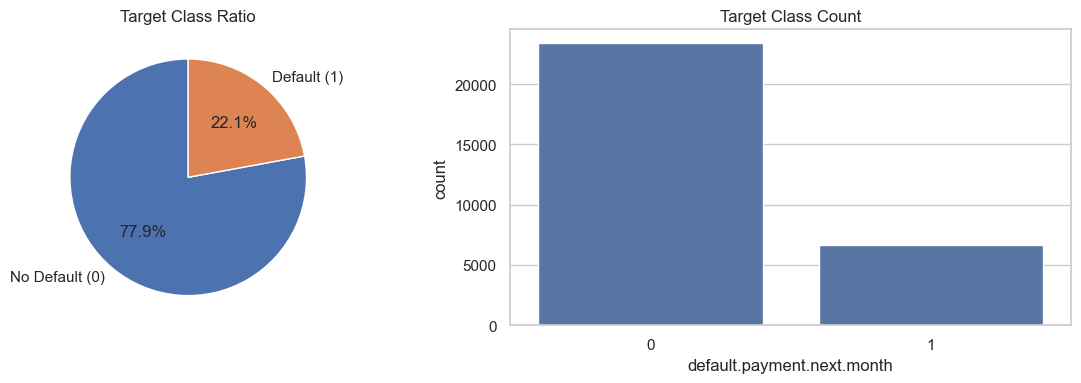

Class percentage (%):
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [9]:
import matplotlib.pyplot as plt

class_counts = df[target_col].value_counts().sort_index()
class_pct = df[target_col].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(
    class_counts.values,
    labels=["No Default (0)", "Default (1)"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Target Class Ratio")

sns.countplot(data=df, x=target_col, ax=axes[1])
axes[1].set_title("Target Class Count")
plt.tight_layout()
plt.show()

print("Class percentage (%):")
print(class_pct.round(2))

The target is imbalanced (~22% default). This means **Accuracy alone is misleading** —
a model that always predicts "No Default" would score ~78% accuracy but catch zero actual defaults.

We will prioritize **F1-score and Recall** throughout model evaluation.

## 4) Exploratory Data Analysis (EDA)

### 4.1 Numerical Feature Patterns

We first inspect key numerical features by target class.

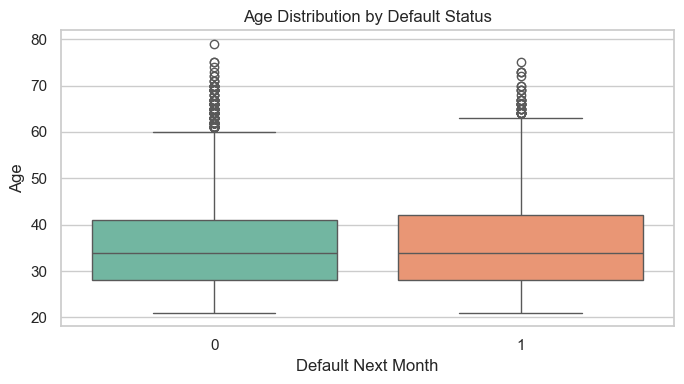

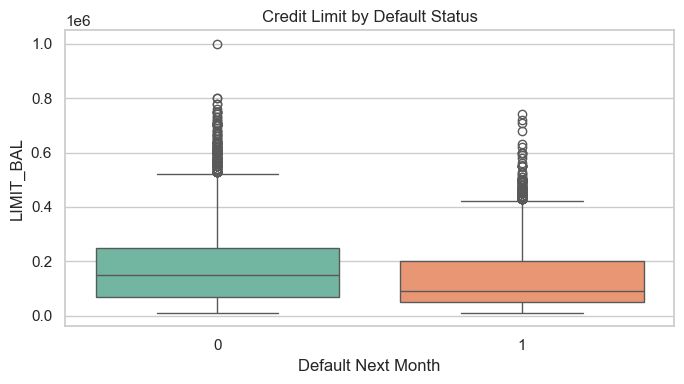

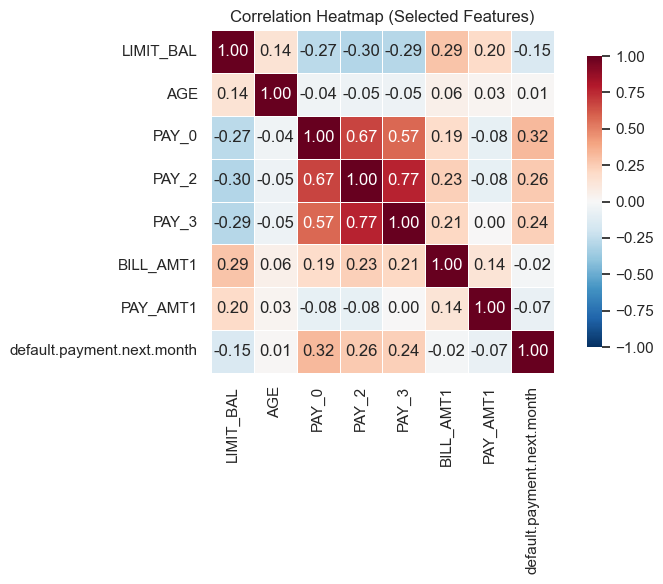

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# AGE by target
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x=target_col, y="AGE", palette="Set2")
plt.title("Age Distribution by Default Status")
plt.xlabel("Default Next Month")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# LIMIT_BAL by target
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x=target_col, y="LIMIT_BAL", palette="Set2")
plt.title("Credit Limit by Default Status")
plt.xlabel("Default Next Month")
plt.ylabel("LIMIT_BAL")
plt.tight_layout()
plt.show()

# Correlation heatmap for selected useful columns
corr_cols = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "BILL_AMT1",
    "PAY_AMT1",
    target_col,
]
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(8.5, 6))
sns.heatmap(
    df[corr_cols].corr(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.85},
)
plt.title("Correlation Heatmap (Selected Features)")
plt.tight_layout()
plt.show()

### 4.2 Categorical Risk Gaps

Here we check default-rate differences by category groups.

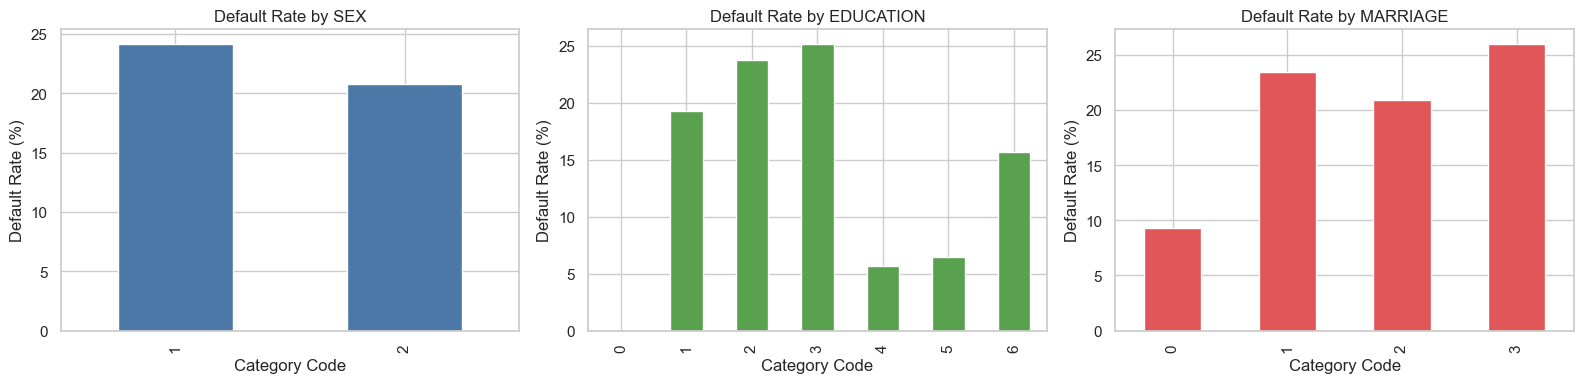

,Group,Default_rate_gap_pct
0,SEX,3.39
1,EDUCATION,25.16
2,MARRIAGE,16.75


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sex_rate = df.groupby("SEX")[target_col].mean().sort_index() * 100
edu_rate = df.groupby("EDUCATION")[target_col].mean().sort_index() * 100
mar_rate = df.groupby("MARRIAGE")[target_col].mean().sort_index() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sex_rate.plot(kind="bar", color="#4C78A8", ax=axes[0], title="Default Rate by SEX")
axes[0].set_ylabel("Default Rate (%)")

edu_rate.plot(kind="bar", color="#59A14F", ax=axes[1], title="Default Rate by EDUCATION")
axes[1].set_ylabel("Default Rate (%)")

mar_rate.plot(kind="bar", color="#E15759", ax=axes[2], title="Default Rate by MARRIAGE")
axes[2].set_ylabel("Default Rate (%)")

for ax in axes:
    ax.set_xlabel("Category Code")

plt.tight_layout()
plt.show()

eda_gap_summary = pd.DataFrame(
    {
        "Group": ["SEX", "EDUCATION", "MARRIAGE"],
        "Default_rate_gap_pct": [
            float(sex_rate.max() - sex_rate.min()),
            float(edu_rate.max() - edu_rate.min()),
            float(mar_rate.max() - mar_rate.min()),
        ],
    }
)
display(eda_gap_summary.style.format({"Default_rate_gap_pct": "{:.2f}"}))

### 4.3 Payment Behavior Analysis (Key Credit-Risk Signal)

Default behavior is strongly related to repayment dynamics, so we analyze PAY, BILL, and PAY_AMT groups together.

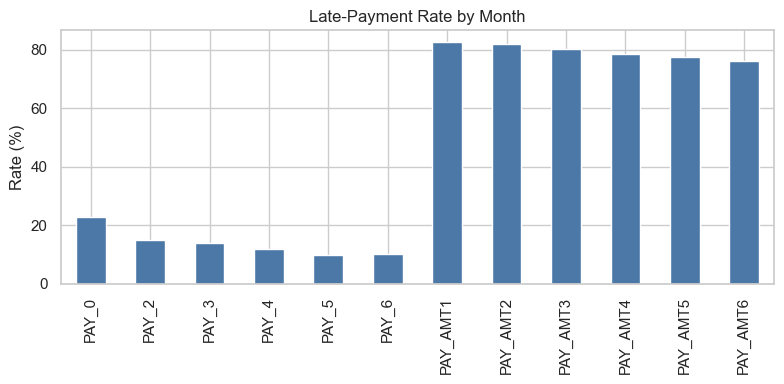

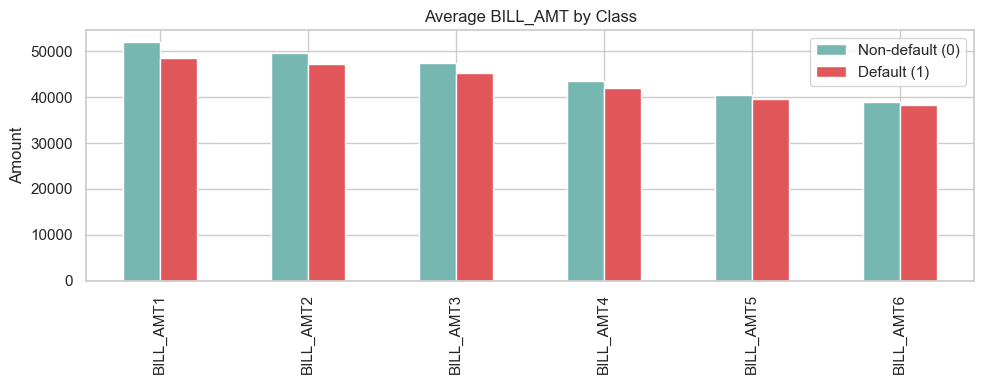

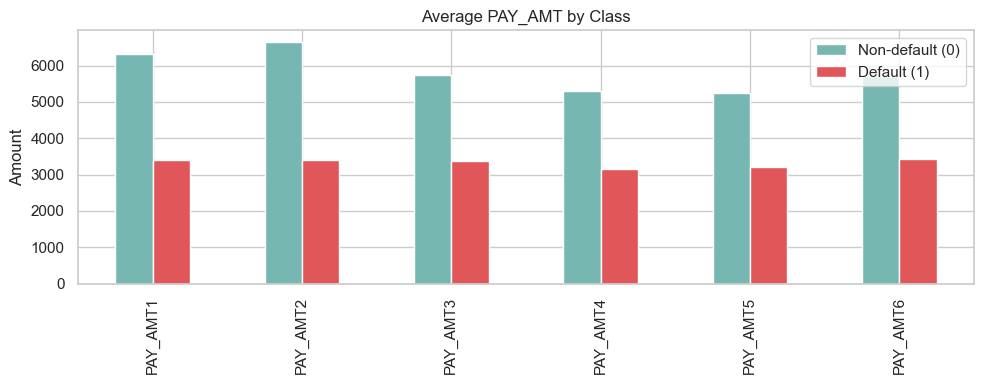

In [10]:
import matplotlib.pyplot as plt

pay_cols = [c for c in df.columns if c.startswith("PAY_") and c != target_col]
bill_cols = [c for c in df.columns if c.startswith("BILL_AMT")]
pay_amt_cols = [c for c in df.columns if c.startswith("PAY_AMT")]

# 1) Late-payment rate by month (PAY_* > 0)
late_rate = (df[pay_cols] > 0).mean().sort_index() * 100
plt.figure(figsize=(8, 4))
late_rate.plot(kind="bar", color="#4C78A8")
plt.title("Late-Payment Rate by Month")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()

# 2) Average bill amount by class
bill_compare = pd.DataFrame(
    {
        "Non-default (0)": df[df[target_col] == 0][bill_cols].mean(),
        "Default (1)": df[df[target_col] == 1][bill_cols].mean(),
    }
)
bill_compare.plot(kind="bar", figsize=(10, 4), color=["#76B7B2", "#E15759"])
plt.title("Average BILL_AMT by Class")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

# 3) Average payment amount by class
pay_compare = pd.DataFrame(
    {
        "Non-default (0)": df[df[target_col] == 0][pay_amt_cols].mean(),
        "Default (1)": df[df[target_col] == 1][pay_amt_cols].mean(),
    }
)
pay_compare.plot(kind="bar", figsize=(10, 4), color=["#76B7B2", "#E15759"])
plt.title("Average PAY_AMT by Class")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

### 4.4 Predictor-Focused Mini Analysis (Simple but Clear)

This part adds a small, focused analysis for key predictor groups:
- `PAY_0..PAY_6` (delinquency level)
- `BILL_AMT1..BILL_AMT6` (bill pressure)
- `PAY_AMT1..PAY_AMT6` (repayment behavior)

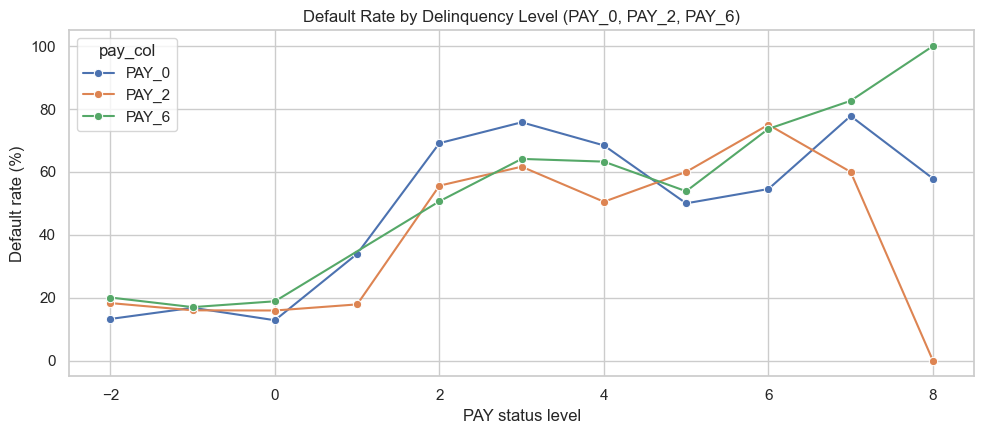

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- A) PAY status vs default rate (representative months) ---
pay_focus_cols = [c for c in ["PAY_0", "PAY_2", "PAY_6"] if c in df.columns]

pay_default_rows = []
for col in pay_focus_cols:
    tmp = df.groupby(col)[target_col].mean().reset_index()
    tmp.columns = ["status_level", "default_rate"]
    tmp["pay_col"] = col
    pay_default_rows.append(tmp)

pay_default_df = pd.concat(pay_default_rows, ignore_index=True)
pay_default_df["default_rate_pct"] = pay_default_df["default_rate"] * 100

plt.figure(figsize=(10, 4.5))
sns.lineplot(
    data=pay_default_df,
    x="status_level",
    y="default_rate_pct",
    hue="pay_col",
    marker="o",
)
plt.title("Default Rate by Delinquency Level (PAY_0, PAY_2, PAY_6)")
plt.xlabel("PAY status level")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

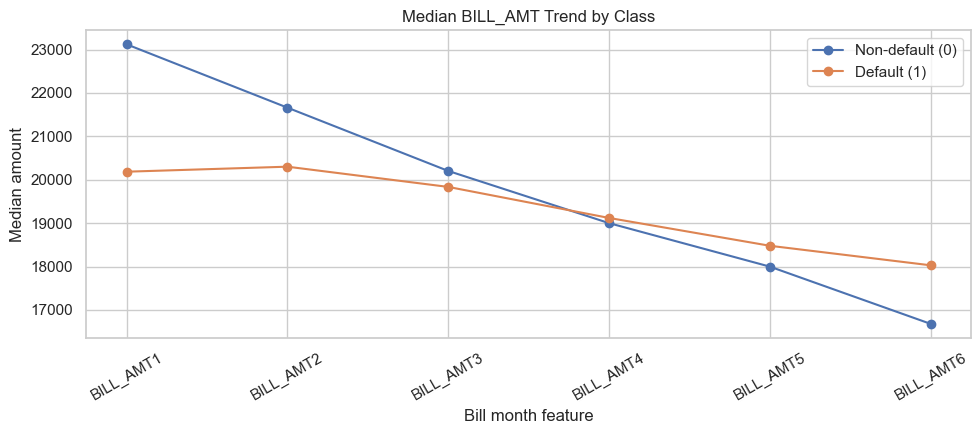

In [12]:
import matplotlib.pyplot as plt

# --- B) Median BILL_AMT by class over 6 months ---
bill_median = pd.DataFrame(
    {
        "Non-default (0)": df[df[target_col] == 0][bill_cols].median(),
        "Default (1)": df[df[target_col] == 1][bill_cols].median(),
    }
)

plt.figure(figsize=(10, 4.5))
plt.plot(bill_median.index, bill_median["Non-default (0)"], marker="o", label="Non-default (0)")
plt.plot(bill_median.index, bill_median["Default (1)"], marker="o", label="Default (1)")
plt.title("Median BILL_AMT Trend by Class")
plt.xlabel("Bill month feature")
plt.ylabel("Median amount")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

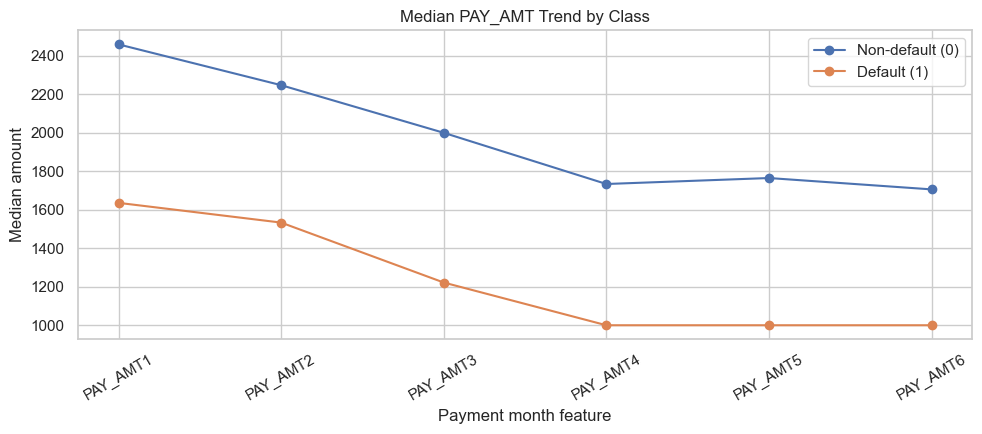

In [13]:
import matplotlib.pyplot as plt

# --- C) Median PAY_AMT by class over 6 months ---
pay_median = pd.DataFrame(
    {
        "Non-default (0)": df[df[target_col] == 0][pay_amt_cols].median(),
        "Default (1)": df[df[target_col] == 1][pay_amt_cols].median(),
    }
)

plt.figure(figsize=(10, 4.5))
plt.plot(pay_median.index, pay_median["Non-default (0)"], marker="o", label="Non-default (0)")
plt.plot(pay_median.index, pay_median["Default (1)"], marker="o", label="Default (1)")
plt.title("Median PAY_AMT Trend by Class")
plt.xlabel("Payment month feature")
plt.ylabel("Median amount")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Mini-Insights (Credit Risk Language)

- **Delinquency effect:** higher PAY status levels are associated with higher default probability.
- **Bill pressure:** the default group tends to carry larger median bill balances.
- **Repayment behavior:** when bill pressure is high but repayment amount is relatively low, repayment stress increases.

### EDA Findings (Simple Explanation)

- The target is imbalanced, so we should not trust Accuracy alone.
- Repayment history (`PAY_*`) shows strong risk signal for default.
- Monetary columns are heavy-tailed and need robust preprocessing.
- Category anomalies (`EDUCATION`, `MARRIAGE`) should be cleaned first.
- Behavior features (utilization and payment intensity) are likely useful.

## 5) Preprocessing and Feature Engineering

### Goal
Prepare data in a clean and reproducible way, based on EDA findings.

### Steps
1. Fix invalid category labels
2. Cap outliers for monetary columns
3. Engineer behavior features
4. Reduce skew for highly skewed money variables
5. Split data with stratification
6. Build one shared preprocessing pipeline for all models

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

clean_df = df.copy()

# 1) Fix uncommon category labels
clean_df["EDUCATION"] = clean_df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
clean_df["MARRIAGE"] = clean_df["MARRIAGE"].replace({0: 3})

# 2) Robust outlier capping (1st - 99th percentile)
money_cols = ["LIMIT_BAL"] + bill_cols + pay_amt_cols
for col in money_cols:
    lower = clean_df[col].quantile(0.01)
    upper = clean_df[col].quantile(0.99)
    clean_df[col] = clean_df[col].clip(lower, upper)

# 3) Behavior features
clean_df["AVG_BILL"] = clean_df[bill_cols].mean(axis=1)
clean_df["AVG_PAY_AMT"] = clean_df[pay_amt_cols].mean(axis=1)
clean_df["UTIL_RATIO"] = clean_df["AVG_BILL"] / clean_df["LIMIT_BAL"].replace(0, np.nan)
clean_df["PAY_TO_BILL_RATIO"] = clean_df["AVG_PAY_AMT"] / clean_df["AVG_BILL"].replace(0, np.nan)
clean_df["AVG_PAY_DELAY"] = clean_df[pay_cols].mean(axis=1)
clean_df["MAX_PAY_DELAY"] = clean_df[pay_cols].max(axis=1)
clean_df["PAY_DELAY_VOLATILITY"] = clean_df[pay_cols].std(axis=1)

# 4) Reduce skew by log1p on highly skewed monetary columns
skew_report = clean_df[money_cols].skew().sort_values(ascending=False)
high_skew_cols = skew_report[skew_report > 1.5].index.tolist()
for col in high_skew_cols:
    clean_df[f"LOG_{col}"] = np.log1p(clean_df[col].clip(lower=0))

clean_df = clean_df.replace([np.inf, -np.inf], np.nan)

# Quick checks after preprocessing
print(f"Default rate: {clean_df[target_col].mean() * 100:.2f}%")
print("Missing values after processing:", int(clean_df.isna().sum().sum()))
print("EDUCATION values:", sorted(clean_df["EDUCATION"].unique().tolist()))
print("MARRIAGE values:", sorted(clean_df["MARRIAGE"].unique().tolist()))
print("High-skew transformed columns:", high_skew_cols)

# 5) Train/test split
X = clean_df.drop(columns=[target_col])
y = clean_df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 6) Shared preprocessing pipeline
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols,
        )
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Default rate: 22.12%
Missing values after processing: 866
EDUCATION values: [1, 2, 3, 4]
MARRIAGE values: [1, 2, 3]
High-skew transformed columns: ['PAY_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT1', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'BILL_AMT3', 'BILL_AMT2', 'BILL_AMT1']
Train shape: (24000, 42)
Test shape: (6000, 42)


## 6) Train Models (Run One-by-One)

### Evaluation policy
- Use the same preprocessing pipeline for all models
- Use stratified CV for fair comparison
- Focus on F1-score and Recall (minority default class)

> Each model is placed in a separate cell so you can run and explain them one at a time.

In [15]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

scores = []
model_pipelines = {}


def evaluate_model(name, estimator):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    scores.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1-score": f1_score(y_test, pred),
            "CV F1": cv_f1,
            "ROC-AUC": roc_auc_score(y_test, prob),
        }
    )

    model_pipelines[name] = pipe

    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred, digits=4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


print("Ready. Run model cells below one-by-one.")

Ready. Run model cells below one-by-one.


### 6.1 Logistic Regression


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.8768    0.7644    0.8167      4673
           1     0.4283    0.6217    0.5072      1327

    accuracy                         0.7328      6000
   macro avg     0.6526    0.6930    0.6620      6000
weighted avg     0.7776    0.7328    0.7483      6000



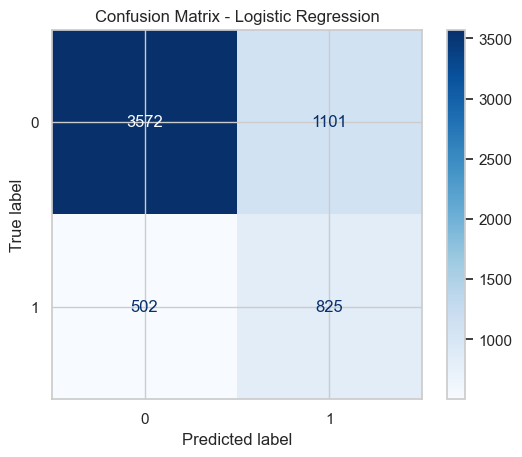

In [16]:
evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
)

### 6.2 K-Nearest Neighbors (KNN)


=== KNN ===
              precision    recall  f1-score   support

           0     0.8279    0.9480    0.8839      4673
           1     0.6256    0.3060    0.4109      1327

    accuracy                         0.8060      6000
   macro avg     0.7267    0.6270    0.6474      6000
weighted avg     0.7831    0.8060    0.7793      6000



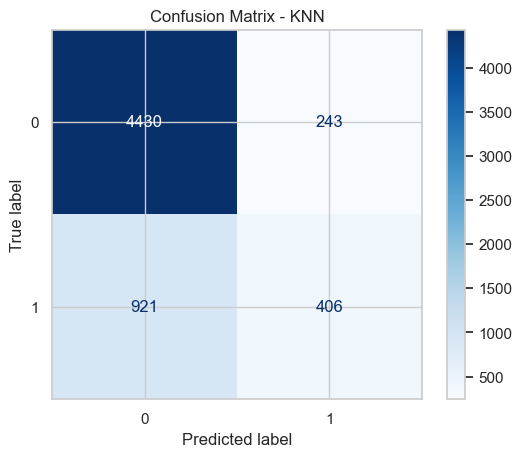

In [17]:
evaluate_model("KNN", KNeighborsClassifier(n_neighbors=15))

### 6.3 Naive Bayes


=== Naive Bayes ===
              precision    recall  f1-score   support

           0     0.8892    0.4430    0.5913      4673
           1     0.2911    0.8056    0.4277      1327

    accuracy                         0.5232      6000
   macro avg     0.5901    0.6243    0.5095      6000
weighted avg     0.7569    0.5232    0.5551      6000



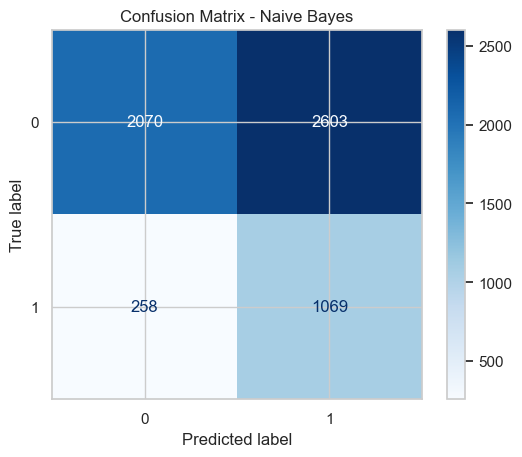

In [18]:
evaluate_model("Naive Bayes", GaussianNB())

### 6.4 Decision Tree


=== Decision Tree ===
              precision    recall  f1-score   support

           0     0.8686    0.8136    0.8402      4673
           1     0.4633    0.5667    0.5098      1327

    accuracy                         0.7590      6000
   macro avg     0.6660    0.6902    0.6750      6000
weighted avg     0.7790    0.7590    0.7671      6000



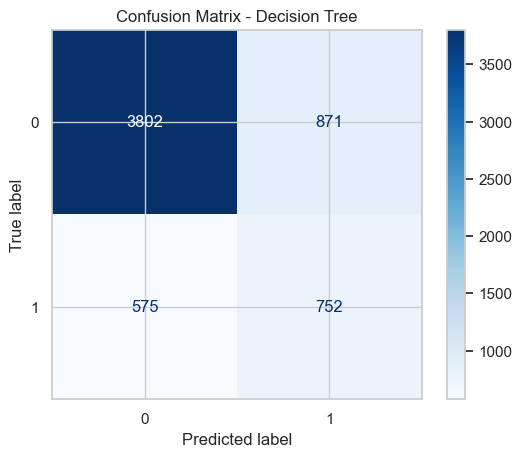

In [19]:
evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
)

### 6.5 Random Forest


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.8703    0.8560    0.8631      4673
           1     0.5207    0.5509    0.5353      1327

    accuracy                         0.7885      6000
   macro avg     0.6955    0.7034    0.6992      6000
weighted avg     0.7930    0.7885    0.7906      6000



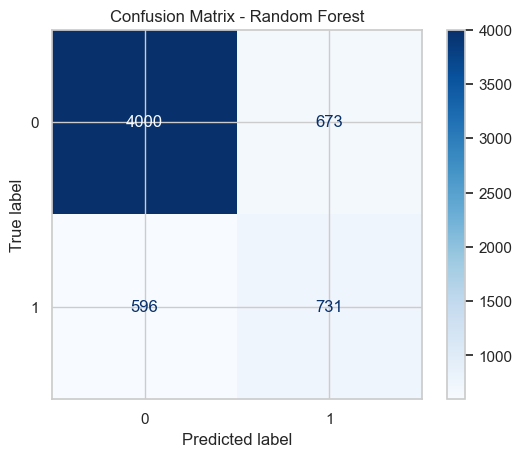

In [20]:
evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
)

## 7) Model Comparison Table

In [21]:
results_df = pd.DataFrame(scores).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score", "CV F1", "ROC-AUC"]]
display(results_df.style.format({c: "{:.4f}" for c in results_df.columns if c != "Model"}))

,Model,Accuracy,Precision,Recall,F1-score,CV F1,ROC-AUC
0,Random Forest,0.7885,0.5207,0.5509,0.5353,0.5405,0.7750
1,Decision Tree,0.7590,0.4633,0.5667,0.5098,0.5212,0.7525
2,Logistic Regression,0.7328,0.4283,0.6217,0.5072,0.5137,0.7433
3,Naive Bayes,0.5232,0.2911,0.8056,0.4277,0.4311,0.7237
4,KNN,0.8060,0.6256,0.3060,0.4109,0.4061,0.7404


### How to Read This Table

- **Accuracy**: overall correctness
- **Precision**: among predicted defaults, how many are truly default
- **Recall**: among true defaults, how many are caught
- **F1-score**: best balance between Precision and Recall (main metric here)
- **CV F1**: consistency across folds
- **ROC-AUC**: probability ranking quality

## 8) Practical Prediction Demo (Best Model)

This helps explain to non-technical audience how output probability becomes a final decision.

In [22]:
best_name = results_df.iloc[0]["Model"]
best_pipe = model_pipelines[best_name]

sample_X = X_test.head(8)
sample_prob = best_pipe.predict_proba(sample_X)[:, 1]
sample_pred = (sample_prob >= 0.5).astype(int)

sample_out = pd.DataFrame(
    {
        "pred_prob_default": sample_prob,
        "pred_label": sample_pred,
        "actual": y_test.head(8).values,
    },
    index=sample_X.index,
)

print("Best model by F1-score:", best_name)
display(sample_out.style.format({"pred_prob_default": "{:.4f}"}))

Best model by F1-score: Random Forest


,pred_prob_default,pred_label,actual
6907,0.3105,0,0
24575,0.3621,0,0
26766,0.3812,0,0
2156,0.3527,0,1
3179,0.1194,0,0
29382,0.4772,0,0
24454,0.2586,0,0
23886,0.1211,0,0


## 9) Final Conclusion and Recommendation

- This project follows a full ML workflow: data understanding, quality audit, EDA, preprocessing, and model comparison.
- EDA and feature engineering focus on credit-risk behavior (`PAY_*`, billing pressure, repayment intensity), not only demographics.
- Because the target is imbalanced, **F1-score and Recall** are more important than Accuracy alone.

### Recommended model for this project
- Use the model with the best F1-score from the comparison table as the primary candidate.
- Reason: it gives better balance between catching defaults (Recall) and keeping prediction quality (Precision).

### Practical risk note
- Main risk in deployment is **false negatives** (missing real default cases).
- In practice, this can be reduced by monitoring model performance over time and retraining periodically.